# **GRUPO 3**

Integrantes:
- Juan Carlos Heredia Vallejo
- Jonathan Fernando Tisalema Lascano

Ciudad de análisis: Hawai

**Nota:** A fin de identificar las modificaciones realizadas, las mismas serán identificadas por ** antes de su título o párrafo correspondiente

<small>
Feedback recibido:

- Ausencia de "Storytelling" deben utilizar celdas de texto (Markdown) para estructurar el análisis. La regla es: Contexto antes del gráfico (¿Qué vamos a ver y por qué?) y Conclusión después del gráfico (¿Qué significa esto para el negocio?). Las respuestas en la sección de Reflexión también son excesivamente breves y parecen cortadas, lo que refuerza la falta de profundidad.
- Al no filtrar los outliers extremos para la visualización o no ajustar los límites de los ejes, las "cajas" quedaron aplastadas contra el eje Y, haciendo imposible comparar las medianas entre Hawaii, Maui y Honolulu. Dediquen tiempo a la estética del gráfico. Si hay outliers visuales que rompen la escala, usen showfliers=False en el boxplot o limiten el eje Y (plt.ylim).
</small>

# Insumos

In [ ]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion tablas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# 1. INGENIERIA DE DATOS y LIMPIEZA

** El presente trabajo utiliza información de los Airbnb registrados en Hawai, los cuales serán analizados para identificar criterios de valor como: Qué barrios son los más rentables, Qué características (amenidades) son las más comunes, qué alojamientos son lo más visitados, entre otros.

A fin de identificar los datos a trabajar, realizamos la carga de los datos, posterior a ello revisamos el tipo de variables que manejamos y los principales estadísticos de las variables numéricas.

In [ ]:
# Cargar base de datos, realizar un info y describe
data = pd.read_csv("listings.csv.gz", encoding='utf-8')
bdd = data.copy()
bdd
# Revisión de tipo de datos
print("Info:\n")
data.info()
# Estadísticos de variables numéricas
print(f"\nDescribe:\n {data.describe()}")

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33457 entries, 0 to 33456
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            33457 non-null  int64  
 1   listing_url                                   33457 non-null  object 
 2   scrape_id                                     33457 non-null  int64  
 3   last_scraped                                  33457 non-null  object 
 4   source                                        33457 non-null  object 
 5   name                                          33457 non-null  object 
 6   description                                   32447 non-null  object 
 7   neighborhood_overview                         16427 non-null  object 
 8   picture_url                                   33457 non-null  object 
 9   host_id                                       33457 no

** Se ha detectado la variable 'price' como tipo objeto, siendo una inconsistencia ya que un valor de venta es naturalmente un valor numérico, por ende se realiza el tratamiento respectivo a la variable. Caso similar con la variable 'last_reviwew'

In [ ]:

# Limpiar la variable price
print(f"\nVARIABLE PRICE\nNúmero de filas: {bdd['price'].head(10)}")
# Limpieza de variable
def limpiar_moneda(var1):
    if isinstance(var1, str):
        aux = var1.replace('$','').replace(',','')
        return float(aux)
    return var1

bdd['price'] = bdd['price'].apply(limpiar_moneda)
print(f"Datos faltantes: {sum(bdd['price'].isnull())}")
print(f"Es numérico: {pd.api.types.is_numeric_dtype(bdd['price'])}")
print(f"Tipo de dato: {bdd['price'].dtype}")

# transformar 'last_review' a fecha
bdd['last_review2'] = pd.to_datetime(bdd['last_review'])
# Comparar var object vs var datetime
bdd[['last_review','last_review2']].head(10)

# Transformar a variable categoria
bdd['room_type'] = bdd['room_type'].astype('category')
print(bdd['room_type'].cat.categories)



VARIABLE PRICE
Número de filas: 0    $136.00
1    $122.00
2    $117.00
3    $150.00
4    $149.00
5    $275.00
6    $279.00
7    $124.00
8    $165.00
9    $311.00
Name: price, dtype: object
Datos faltantes: 325
Es numérico: True
Tipo de dato: float64
Index(['Entire home/apt', 'Hotel room', 'Private room', 'Shared room'], dtype='object')


** Identificar los datos nulos es crucial porque su presencia puede distorsionar los análisis, generar errores en los cálculos estadísticos, y llevar a conclusiones erróneas. Al identificar el comportamiento de los valores faltantes, podemos decidir las estrategias de imputación más adecuadas o la necesidad de limpiar esos datos, asegurando así la calidad de análisis y, por ende, de las decisiones de negocio que se tomen a partir de ellos.

In [ ]:
# Proporción de datos nulos por columna
print("\n\nProporción de datos nulos:\n")
nulos = (bdd.isna().mean() * 100).sort_values(ascending=False)
tipos = bdd.dtypes
resumen = pd.DataFrame({
    "porcentaje_nulos": nulos,
    "tipo_dato": tipos[nulos.index]  # alineamos con el orden de 'nulos'
})
print(resumen)



Proporción de datos nulos:

                                              porcentaje_nulos       tipo_dato
calendar_updated                                    100.000000         float64
neighborhood_overview                                50.901157          object
neighbourhood                                        50.901157          object
host_about                                           30.322504          object
host_location                                        25.062020          object
host_neighbourhood                                   22.144843          object
review_scores_cleanliness                            20.115372         float64
review_scores_location                               20.115372         float64
review_scores_checkin                                20.115372         float64
review_scores_communication                          20.115372         float64
review_scores_value                                  20.115372         float64
review_scores_accuracy

** Se identifican algunas variables con datos faltantes. Sin embargo, se identifica faltantes en la varible 'price' siendo un factor vital para el presente análisis, dado esto se procede a imputar con la mediana del precio según su ubicación y tipo de alojamiento.

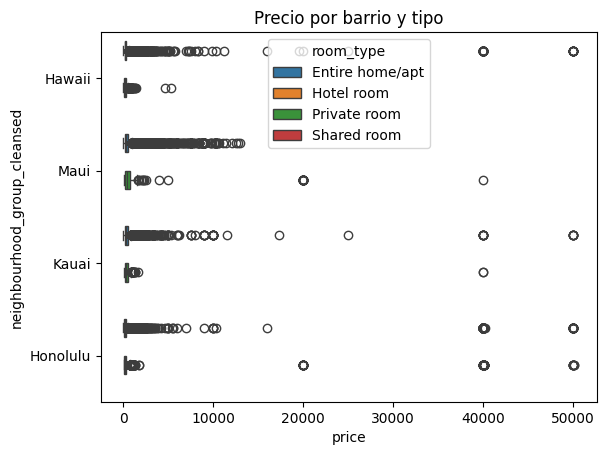

/tmp/ipython-input-3051149366.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medianas = bdd.groupby(['neighbourhood_group_cleansed', 'room_type'])['price'].transform('median')


In [ ]:
# Revisar el comportamiento de la variable price con NaN en grupos por barrio y tipo de habitación
bdd['group'] = bdd['neighbourhood_group_cleansed'].astype(str) + bdd['room_type'].astype(str) #crear id del grupo

sns.boxplot(data=bdd[bdd['group'].isin(bdd.loc[bdd['price'].isnull(),'group'])], y='neighbourhood_group_cleansed', x='price', hue='room_type')
plt.title('Precio por barrio y tipo')
plt.show()

# Se muestan precios muy variados sin una concentración en los distintos barrios
# Se opta por realizar una imputación con el valor de la mediana por barrio y tipo de habitación ya que demuestra ser el estadístico más robsto considerando la dispersión de precios
medianas = bdd.groupby(['neighbourhood_group_cleansed', 'room_type'])['price'].transform('median')
bdd['price'] = bdd['price'].fillna(medianas)

** A fin de conseguir informaicón más detallada, se procede a generar variables de interes:
- price_per_person: _precio del alojamiento / capacidad total del alojamiento_
- is_luxury: _se considerará lujoso a los alojamientos que estén por encima del percentil 75_

In [ ]:
# Crear variable price_per_person
bdd['price_per_person'] = bdd['price']/bdd['accommodates']

# Crear variable is_luxury
p75 = bdd.groupby('neighbourhood_cleansed')['price'].transform(lambda x: x.quantile(0.75))
bdd['is_luxury'] = (bdd['price'] > p75).astype(int)

bdd.groupby('neighbourhood_cleansed')['is_luxury'].mean()*100


,is_luxury
neighbourhood_cleansed,
Central Oahu,25.000000
East Honolulu,24.712644
Ewa,24.909311
Hamakua,25.806452
Hana,25.316456
Kapaa-Wailua,25.029516
Kau,24.043716
Kihei-Makena,24.983180
Koloa-Poipu,25.030230


** Desde un criterio personal se han considerado ciertas amenidades como escenciales y se opta por identificar qué alojamientos poseen de estos mediante la identificación de los mismos, en una variable con una lista de amenidades, y posterior con la creación de varibles binarias para cada amenidad de interes.

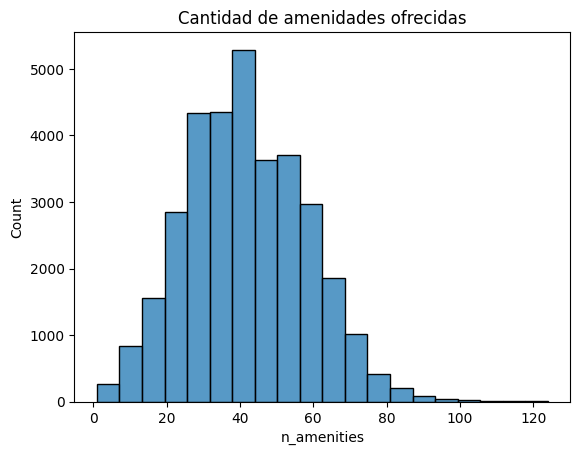

Proporción de amenidades principales en los alojamientos: 
ameniti_wifi            98.741668
ameniti_hot_water       84.816331
ameniti_refrigerator    83.002062
ameniti_kitchen         91.723705
ameniti_parking         91.099023
dtype: float64


In [ ]:
# Conteo de amenidades
def conteo_amenidades(var1):
    if isinstance(var1, str):
        aux = len(var1.split(','))
        return aux
    return var1

bdd['n_amenities']=bdd['amenities'].apply(conteo_amenidades)

sns.histplot(data=bdd, x='n_amenities', bins=20)
plt.title('Cantidad de amenidades ofrecidas')
plt.show()

# Crear variables binarias de amenities específicas
bdd['ameniti_wifi'] = bdd['amenities'].str.lower().str.contains('wifi')*1
bdd['ameniti_hot_water'] = bdd['amenities'].str.lower().str.contains('hot water')*1
bdd['ameniti_refrigerator'] = bdd['amenities'].str.lower().str.contains('refrigerator')*1
bdd['ameniti_kitchen'] = bdd['amenities'].str.lower().str.contains('kitchen')*1
bdd['ameniti_parking'] = bdd['amenities'].str.lower().str.contains('parking')*1

print(f"Proporción de amenidades principales en los alojamientos: \n{bdd[['ameniti_wifi','ameniti_hot_water','ameniti_refrigerator','ameniti_kitchen','ameniti_parking']].mean()*100}")
#La distribución de n_amenities parece seguir una distribución normal, con un promedio aproximado de 40 amenidades por alojamiento en Hawai


# 2. ANALISIS EXPLORATORIO (EDA)

El Análisis Exploratorio de Datos (EDA) es una fase crucial en el proceso de análisis de datos que consiste en utilizar técnicas estadísticas y visuales para comprender las características principales de un conjunto de datos. Su objetivo es descubrir patrones, detectar anomalías, probar hipótesis y verificar supuestos, lo que ayuda a guiar la selección de modelos y a refinar las preguntas de investigación, garantizando una comprensión profunda de la información.

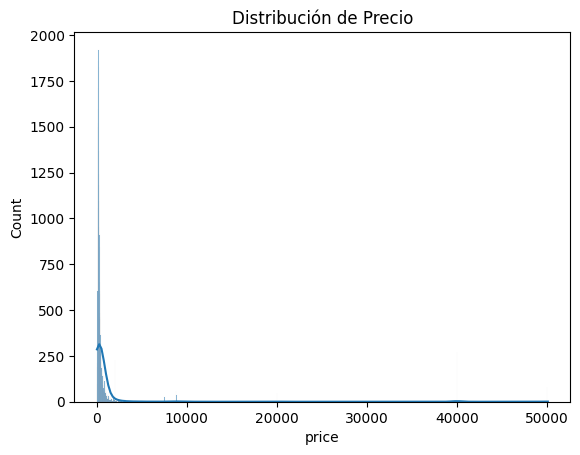

In [ ]:
# Revisar la distribución de la variable prices
sns.histplot(data=bdd, x='price', kde=True)
plt.title('Distribución de Precio')
plt.show()
#No se observa una distribución normal, debido a la existencia de datos atípicos

La distribución de precios presenta una acumulacióm de datos a la izquierda, lo cual puede deberse a presencia de datos outliers, para ello se excluirán estos datos del gráfico.

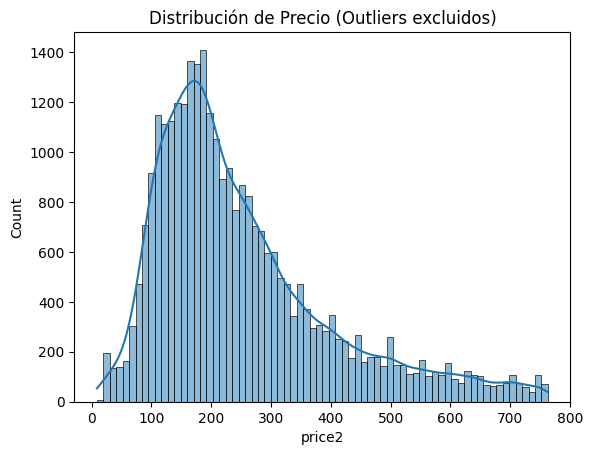

In [ ]:
#Excluir datos outliers
Q1 = bdd["price"].quantile(0.25)
Q3 = bdd["price"].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

bdd['price2'] = np.where(
    (bdd["price"] < lim_inf) | (bdd["price"] > lim_sup),
    np.nan,
    bdd['price']
)

# Revisar la distribución de la variable prices (sin outliers)
sns.histplot(data=bdd, x='price2', kde=True)
plt.title('Distribución de Precio (Outliers excluidos)')
plt.show()

La distribución del la variable precio, aún excluyendo outliers, presenta un sesgo a la derecha. Por lo tanto, no se asemeja a una distribución normal

** A fin de analizar la distribución de precios por tipo de alojamiento, se realiza una gráfica boxplot desagregada para observar el comportamiento de los mismos

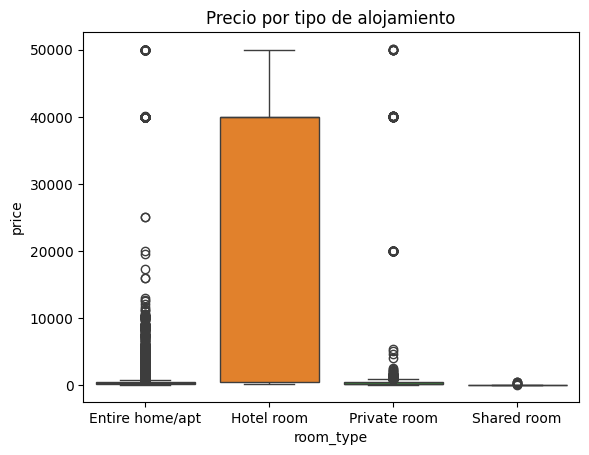

In [ ]:
# Boxplot: Precio y Tipo de alojamiento
sns.boxplot(data=bdd, x='room_type', y='price', hue='room_type')
plt.title('Precio por tipo de alojamiento')
plt.show()

** En una primera vista no se observa adecuadamenta la distirbución ya que el precio de hoteles son sumamente elevados.
Además, El tipo de alojamiento 'casa completa' presenta mayor dispersión en sus datos (con muchos datos atípicos frente a sus principales cuartiles).
Por ello, se opta por analizar gráficos independientes:

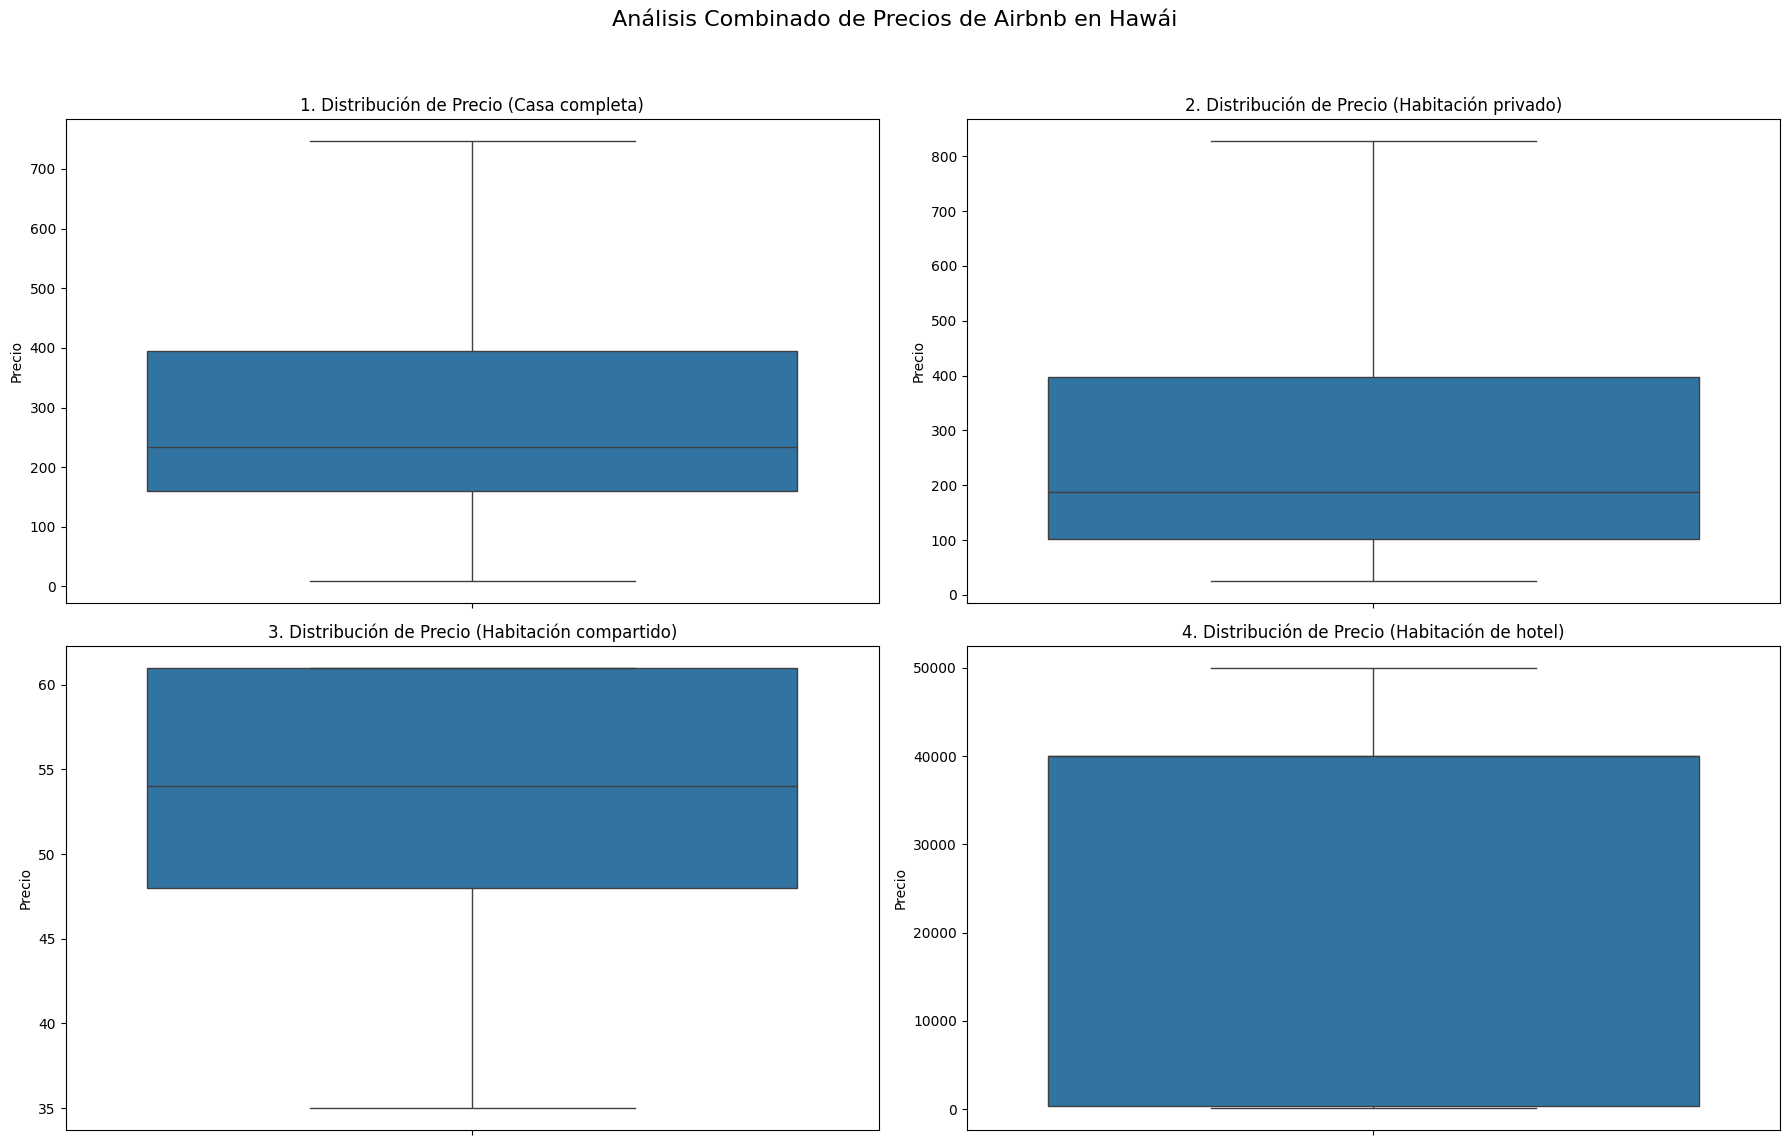

In [ ]:
#** Se acoge feedback de visualizar gráficos de una mejor manera

# Crear figura agrupada
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis Combinado de Precios de Airbnb en Hawái', fontsize=16)

# Boxplot: Precio por 'Casa completa'
sns.boxplot(data=bdd[bdd['room_type']=='Entire home/apt'], y='price', showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title('1. Distribución de Precio (Casa completa)')
axes[0, 0].set_xlabel(None)
axes[0, 0].set_ylabel('Precio')

sns.boxplot(data=bdd[bdd['room_type']=='Private room'], y='price', showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title('2. Distribución de Precio (Habitación privado)')
axes[0, 1].set_xlabel(None)
axes[0, 1].set_ylabel('Precio')

sns.boxplot(data=bdd[bdd['room_type']=='Shared room'], y='price', showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title('3. Distribución de Precio (Habitación compartido)')
axes[1, 0].set_xlabel(None)
axes[1, 0].set_ylabel('Precio')

sns.boxplot(data=bdd[bdd['room_type']=='Hotel room'], y='price', ax=axes[1, 1])
axes[1, 1].set_title('4. Distribución de Precio (Habitación de hotel)')
axes[1, 1].set_xlabel(None)
axes[1, 1].set_ylabel('Precio')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

** Considerando datos comunes (ni muy bajo, ni muy alto) como los presentes en un rango intercuartil, los precios por tipo de alojamiento estarían ordenados, de económico a costoso, de la siguiente forma:
- Habitación compartida (hasta USD 60 aprox)
- Habitación privada (hasta USD 400 aprox)
- Casa completa (hasta USD 400 aprox)
- Habitación de hotel (hasta USD 40.000 aprox)

** Similar al anaálisis anterior, es importante identificar el lugar más costoso a fin de buscar alternativas de implementación de iun proyecto:

['Primary Urban Center', 'Lahaina', 'North Kona', 'Kapaa-Wailua', 'Lihue', 'North Shore Kauai', 'Waimea-Kekaha', 'Koloa-Poipu', 'South Kohala', 'Ewa']


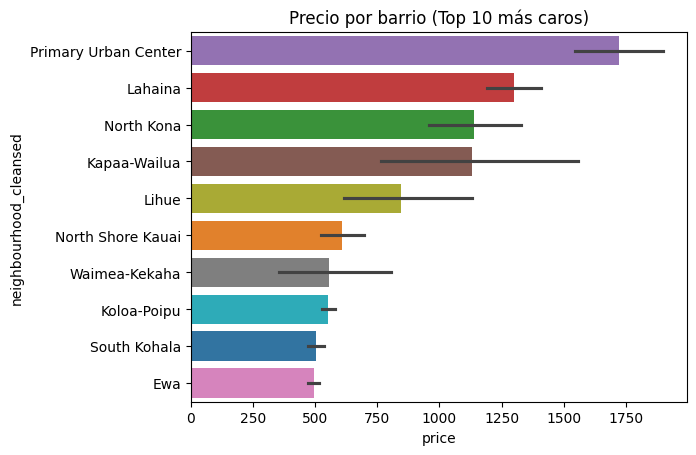

In [ ]:
# Boxplot: Precio y Barrio
top10 = bdd.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10).index.tolist()
print(top10)
# Escoger la media como estadístico más cercano, ya que la mediana podría reducir precios altos

sns.barplot(data=bdd[bdd['neighbourhood_cleansed'].isin(top10)], y='neighbourhood_cleansed', x='price',
            hue='neighbourhood_cleansed', order=top10)
plt.title('Precio por barrio (Top 10 más caros)')
plt.show()

# El barrio Primary Urban Center demuestra ser el barrio más caro en base al precio medio de sus alojamientos

** Los barrios que manejan precios más altos son:
- Primary Urban Center
- Lahaina
- North Kona
- Kapaa-Wailua

** Con el objetivo de eindentificar que factores (entre: capacidad, número de reseñas y rating de calificación) pueden estar realacionados con el precio, se realiza un análisis de correlación para identificar si llevan algún tipo de reaclión directa o inversa:

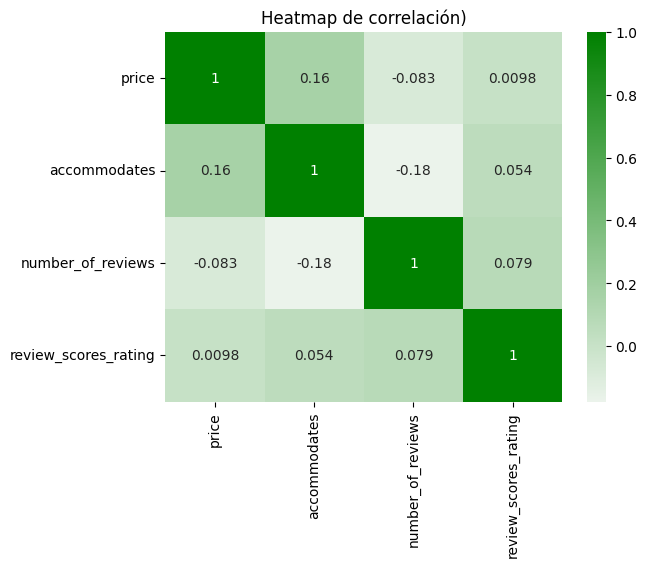

In [ ]:
# Heatmap de correlacion: price, accommodates, number_of_reviews, y review_scores_rating.
corr_mat = bdd[['price','accommodates','number_of_reviews','review_scores_rating']].corr()
sns.heatmap(corr_mat, cmap=sns.light_palette("green", as_cmap=True), annot=True)
plt.title('Heatmap de correlación)')
plt.show()

** La matriz de correlación no demuestra ninguna relación significativa entre las variables analizadas (ningun coeficiente mayor a 0.4)

# 3. VISUALIZACION AVANZADA Y NEGOCIO

** A fin de identificar si los precios altos se deben a un factor grográfico, se realizar un diagrama de dispersion considerando las coordenadas geográficas de los alojamientos:

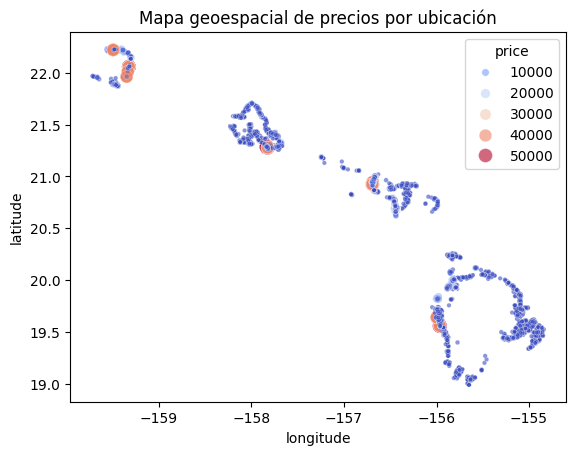

In [ ]:
# 3. VISUALIZACION AVANZADA Y NEGOCIO

# Scatter geoespacial
sns.scatterplot(data=bdd, x='longitude', y='latitude', hue='price', size='price', sizes=(10, 100), palette='coolwarm', alpha=0.6, s=50)
plt.title('Mapa geoespacial de precios por ubicación')
plt.show()
# Los precios más alto presentan concentración en zonas específicas, lo cual puede sugerir una naturalidad de precios o nivel zonal/geográfico.

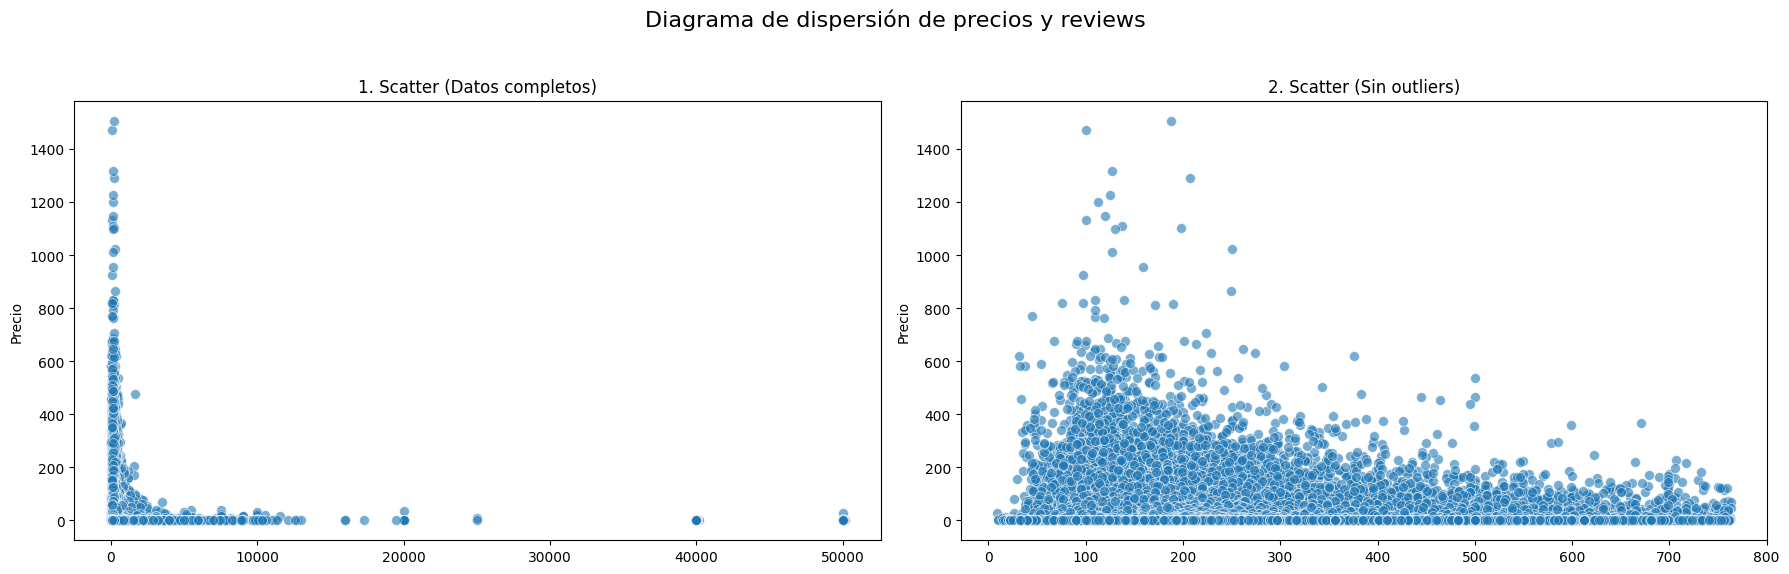

In [ ]:
# Crear figura agrupada
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Diagrama de dispersión de precios y reviews', fontsize=16)

# Scatterplot: reviews y price
sns.scatterplot(data=bdd, x='price', y='number_of_reviews', alpha=0.6, s=50, ax=axes[0])
axes[0].set_title('1. Scatter (Datos completos)')
axes[0].set_xlabel(None)
axes[0].set_ylabel('Precio')

# Scatterplot: reviews y price
sns.scatterplot(data=bdd, x='price2', y='number_of_reviews', alpha=0.6, s=50, ax=axes[1])
axes[1].set_title('2. Scatter (Sin outliers)')
axes[1].set_xlabel(None)
axes[1].set_ylabel('Precio')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

La cantidad de reseñas generalmente no influye directamente en el precio, como se muestra en la matriz de correlación.
El scatter plot entre number_of_reviews y price suele mostrar poca o ninguna correlación clara y los datos outliers pueden distorsionar la relación

# 4. REFLEXION Y BUENAS PRACTICAS

**1. ¿Qué desafíos específicos encontraste al transformar columnas de texto no estructurado (como la lista de amenities o el price con símbolos) en variables numéricas útiles? ¿Cómo impactaría en el negocio si no se hubieran limpiado correctamente estos caracteres antes del análisis?**

<small>** La principal dificultad fue que las columnas no estaban en un formato listo para analizar. En el caso del precio, incluía símbolos como “$”, comas y a veces espacios, lo que hacía que el sistema lo interpretara como texto y no como número. Además, dependiendo del formato, el separador decimal puede cambiar, por lo que era necesario revisar bien cada detalle antes de convertir la variable.
Con la lista de amenities pasó algo parecido. Al ser texto libre, había diferencias en la forma de escribir lo mismo, como “Wifi”, “WiFi” o “wifi”. Aunque para nosotros es lo mismo, para el sistema son valores distintos. Por eso fue importante unificar esos términos para poder analizarlos correctamente.
Si no se hubieran limpiado estas columnas, el análisis podría haber sido incorrecto. Por ejemplo, se podrían comparar mal los precios entre barrios o tipos de alojamiento, afectando decisiones sobre precios o segmentación. También se podría interpretar mal qué servicios son más comunes o más valorados. Por eso, la limpieza de datos es clave para que las conclusiones sean confiables y útiles para el negocio.</small>

**2. Al aplicar el método del Rango Intercuartílico (IQR) para filtrar precios: ¿Consideras que esta técnica fue totalmente efectiva o existe el riesgo de haber eliminado  propiedades de "Lujo" legítimas (información valiosa)? ¿Qué estrategia alternativa propondrías para separar "errores de carga" de "propiedades exclusivas"?**

<small>** Puede no ser la técnica más adecuada en todos los casos, ya que al revisar los precios por barrio se observa que en algunos existen varios datos atípicos que podrían ser útiles para un análisis específico de “alojamientos lujosos”. Es decir, no todos los valores extremos necesariamente son errores, algunos pueden representar una categoría distinta dentro del mercado.
La identificación de un posible error en los datos podría realizarse comparando el precio con otras variables como ubicación, capacidad de alojamiento o cantidad de reseñas. Este análisis puede apoyarse en medidas de tendencia central de variables específicas o en un análisis de clústers como grupos homogéneos, que permita observar si ese valor realmente se comporta de manera muy diferente al resto de propiedades similares.
Por otro lado, el método IQR sí fue útil para eliminar valores claramente poco realistas, como precios en cero o montos excesivamente altos producto de errores de carga. Sin embargo, existe el riesgo de eliminar propiedades de lujo reales. Como alternativa, se podrían analizar los valores extremos por barrio o clasificarlos como propiedades premium en lugar de eliminarlos completamente, evitando así perder información relevante para el análisis.</small>

**3. En el caso de los review_scores_rating faltantes, ¿qué método de imputación elegiste (media, mediana, cero o eliminación) y cómo justificas esa decisión desde la perspectiva del comportamiento del usuario en una plataforma de viajes? (e.g., ¿La ausencia de review significa un servicio promedio o un servicio malo?).**

<small>** En primer lugar, es importante verificar si el número de reviews del alojamiento es mayor a 0. Si no tiene reseñas, la ausencia de puntuación no necesariamente significa que el servicio sea malo o promedio, sino que simplemente no ha sido evaluado. Por eso, antes de imputar datos, se debe filtrar y analizar esa situación.
En los casos donde sí existen reseñas pero falta el valor de review_scores_rating, se podría imputar utilizando la media de puntuaciones de alojamientos con características similares, como el mismo vecindario, tipo de alojamiento o capacidad. De esta manera, la imputación es más coherente con el comportamiento esperado dentro de ese grupo y no altera de forma significativa el análisis.
Desde la perspectiva del usuario en una plataforma de viajes, la falta de reviews suele estar más asociada a un alojamiento nuevo o con poca visibilidad, y no necesariamente a un mal servicio. Por eso, asignar directamente un valor bajo o cero podría distorsionar los resultados y afectar de manera injusta la interpretación del desempeño del alojamiento.</small>

**4. ¿De qué manera la visualización geoespacial (scatter plot con latitud/longitud) reveló patrones de precios que las estadísticas descriptivas (como el simple promedio por barrio) no lograron mostrar?**

<small>** La visualización geoespacial permitió observar los precios según la ubicación exacta de cada propiedad, y no solo agrupados por barrio. A través del scatter plot con latitud y longitud, se pudieron identificar zonas específicas donde los precios son más altos o más bajos dentro de un mismo barrio, algo que no se detecta fácilmente cuando solo se analiza el promedio general.
Las estadísticas descriptivas, como el promedio por barrio, resumen la información y pueden ocultar diferencias internas. En cambio, el mapa permitió ver concentraciones de precios elevados en áreas puntuales, mostrando patrones más detallados. Esto es útil para identificar zonas con mayor potencial de inversión o sectores donde existe una mayor disposición a pagar, aportando una visión más estratégica para la toma de decisiones.</small>
    

**5. Indica al menos dos buenas prácticas que implementarías en un pipeline de ingeniería de datos para automatizar este proceso si tuvieras que recibir este archivo actualizado mes a mes (ej. validación de esquemas, funciones modulares, logs de errores).**

<small>
** Si el archivo se recibiera mes a mes, una buena práctica sería primero identificar y filtrar claramente las variables que se van a utilizar en el análisis. Esto ayuda a trabajar solo con la información relevante y evitar errores innecesarios.
Otra práctica clave sería validar el esquema del archivo, verificar que todas las columnas esperadas existan y que tengan el tipo de dato correcto (por ejemplo, que el precio sea numérico). De esta manera, si el archivo cambia de estructura o viene con errores de carga, el problema se detecta antes de continuar con el proceso.
También sería importante crear funciones separadas para cada etapa del pipeline, como limpieza de precios, imputación de valores nulos y transformación de variables. Esto permite que el proceso sea más ordenado, fácil de mantener y reutilizable cada mes, reduciendo la probabilidad de cometer errores.
Por último, registrar los errores y cambios en los datos ayudaría a detectar inconsistencias a tiempo. Llevar un control de lo que se modifica o se elimina permite tener mayor trazabilidad y asegurar que el análisis sea confiable en el tiempo.
</small>

# 5. APLICACION AL ENTORNO PROFESIONAL

**Cada miembro del equipo colocara su nombre una explicación de como aplicaría lo aprendido en esta semana en su entorno profesional.**

- **Juan:**

    Mi entorno profesional actual está relacionado con gestión de riesgos en el sector financiero. Evaluar la calidad de los datos y  realizar su limpieza, es de suma importancia para asegurarse que las alertas/eventos que se identifiquen sean correctos. Ejemplo: Confirmar que los signos de las cuentas de balance estén correctos. Por otro lado, el identificar el comportamiento de los datos (distribución, correlación, evolución de indicadores) es escencial para determinar tendencias.

- **Jonathan:**

    En mi trabajo como broker de seguros, aplicaría lo aprendido esta semana para mejorar la calidad y el análisis de datos de clientes y pólizas. Por ejemplo, podría limpiar y transformar columnas con información no estructurada, como tipos de cobertura o comentarios de clientes, para convertirlas en variables útiles para análisis o modelos de riesgo. También usaría técnicas como detección de outliers para identificar precios de pólizas o siniestros atípicos, y visualizaciones geoespaciales para detectar patrones de siniestralidad o concentración de clientes por zona. Esto permitiría tomar decisiones más informadas sobre precios, promociones y gestión de riesgos, y automatizar partes del proceso de análisis para hacerlo más eficiente mes a mes.